# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

## Imports

In [1]:
import pandas as pd


## Load and Explore the Data

In [2]:
df = pd.read_csv('data_banknote_authentication.csv')

In [3]:
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [5]:
df['Class'].value_counts()

,count
Class,
0,762
1,610


## Train | Test Split

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## Decision Tree with GridSearchCV

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [10]:
dt_params = {
    'max_depth': [None, 3, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [11]:
dt = DecisionTreeClassifier()
dt_grid = GridSearchCV(dt, dt_params, cv=5)
dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 10]})

In [12]:
dt_grid.best_params_

{'criterion': 'entropy', 'max_depth': None}

## Evaluate Decision Tree

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [14]:
dt_preds = dt_grid.predict(X_test)

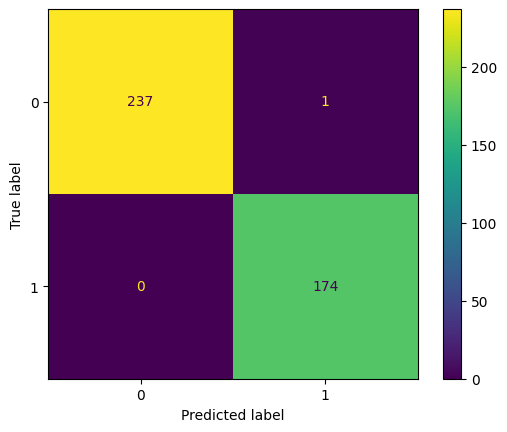

In [15]:
ConfusionMatrixDisplay.from_estimator(dt_grid, X_test, y_test)

In [16]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       0.99      1.00      1.00       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



## Random Forest with GridSearchCV

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

In [19]:
rf = RandomForestClassifier()
rf_grid = GridSearchCV(rf, rf_params, cv=5)
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 200]})

In [20]:
rf_grid.best_params_

{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}

## Evaluate Random Forest

In [21]:
rf_preds = rf_grid.predict(X_test)

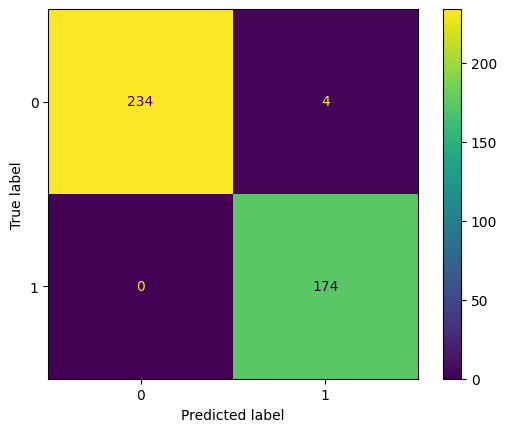

In [22]:
ConfusionMatrixDisplay.from_estimator(rf_grid, X_test, y_test)

In [23]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



## Comparison

Both models performed very well on this dataset.

The Decision Tree after tuning achieved around 99-100% accuracy, and the Random Forest achieved around 99% accuracy.

The Decision Tree here actually performed slightly better or on par with Random Forest because the dataset is relatively clean and well-separated, so a single tree can capture the patterns easily.

In general, Random Forest is more reliable on noisy or complex datasets because it uses multiple trees and averaging, which reduces overfitting. But for this banknote dataset, both models work extremely well.

If we had to pick one for production use, Random Forest would still be the safer choice since it is more robust to unseen data.